In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
coords = pd.read_csv('/mnt/morbo/Data/Users/kwoyshner/cerebellum/results/human_allGenes/coords_human.csv',index_col=0)
meta = pd.read_csv('/mnt/morbo/Data/Users/kwoyshner/cerebellum/data/human_CB_meta.csv',index_col=0)
#meta['Patient_Replicate'] = meta.apply(lambda x: str(x['patient']) + '_' + x['replicate'], axis=1)

#clinical_meta = pd.read_excel('/mnt/morbo/Data/Users/kwoyshner/cerebellum/data/SpatialSeq subject Info(Updated)_subjectAdjusted.xlsx')
clinical_meta = pd.read_excel('/mnt/morbo/Data/Users/kwoyshner/cerebellum/FORGITHUB/cogaps/SpatialSeq subject Info(Updated)_subjectAdjusted_newIDs.xlsx')
clinical_meta['Subject_newID'] = clinical_meta['Subject_newID'].fillna('NA')

clinical_meta_cell = meta.reset_index().merge(clinical_meta, left_on='patient', right_on='Subject', how='left').set_index('index')
clinical_meta_cell['Patient_Replicate'] = clinical_meta_cell.apply(lambda x: str(x['Subject_newID']) + '_' + x['replicate'], axis=1)
clinical_meta_cell['Patient_Replicate_PT'] = clinical_meta_cell.apply(lambda x: x['Patient_Replicate'] + '(' + x['GROUP'] + ')', axis=1)
clinical_meta_cell_sub = clinical_meta_cell[clinical_meta_cell['Subject_newID'] != "NA"] # Drop outlier patient

sorted_meta = clinical_meta_cell_sub.reset_index().groupby('Patient_Replicate').agg('first').sort_values(['GROUP','Patient_Replicate'])
images = [x.split('_')[0] for x in sorted_meta.loc[:,'index']]
hex_colors = pd.read_csv('/mnt/morbo/Data/Users/kwoyshner/cerebellum/projections/tricycle/theta_hex_colors.csv',index_col=0)
hex_colors = hex_colors.set_index('angle')

## Spatial data

In [3]:
tricycle_pos = pd.read_csv('/mnt/morbo/Data/Users/kwoyshner/cerebellum/projections/tricycle/results/human_Spatial/tricyclePosition.csv',index_col=0)

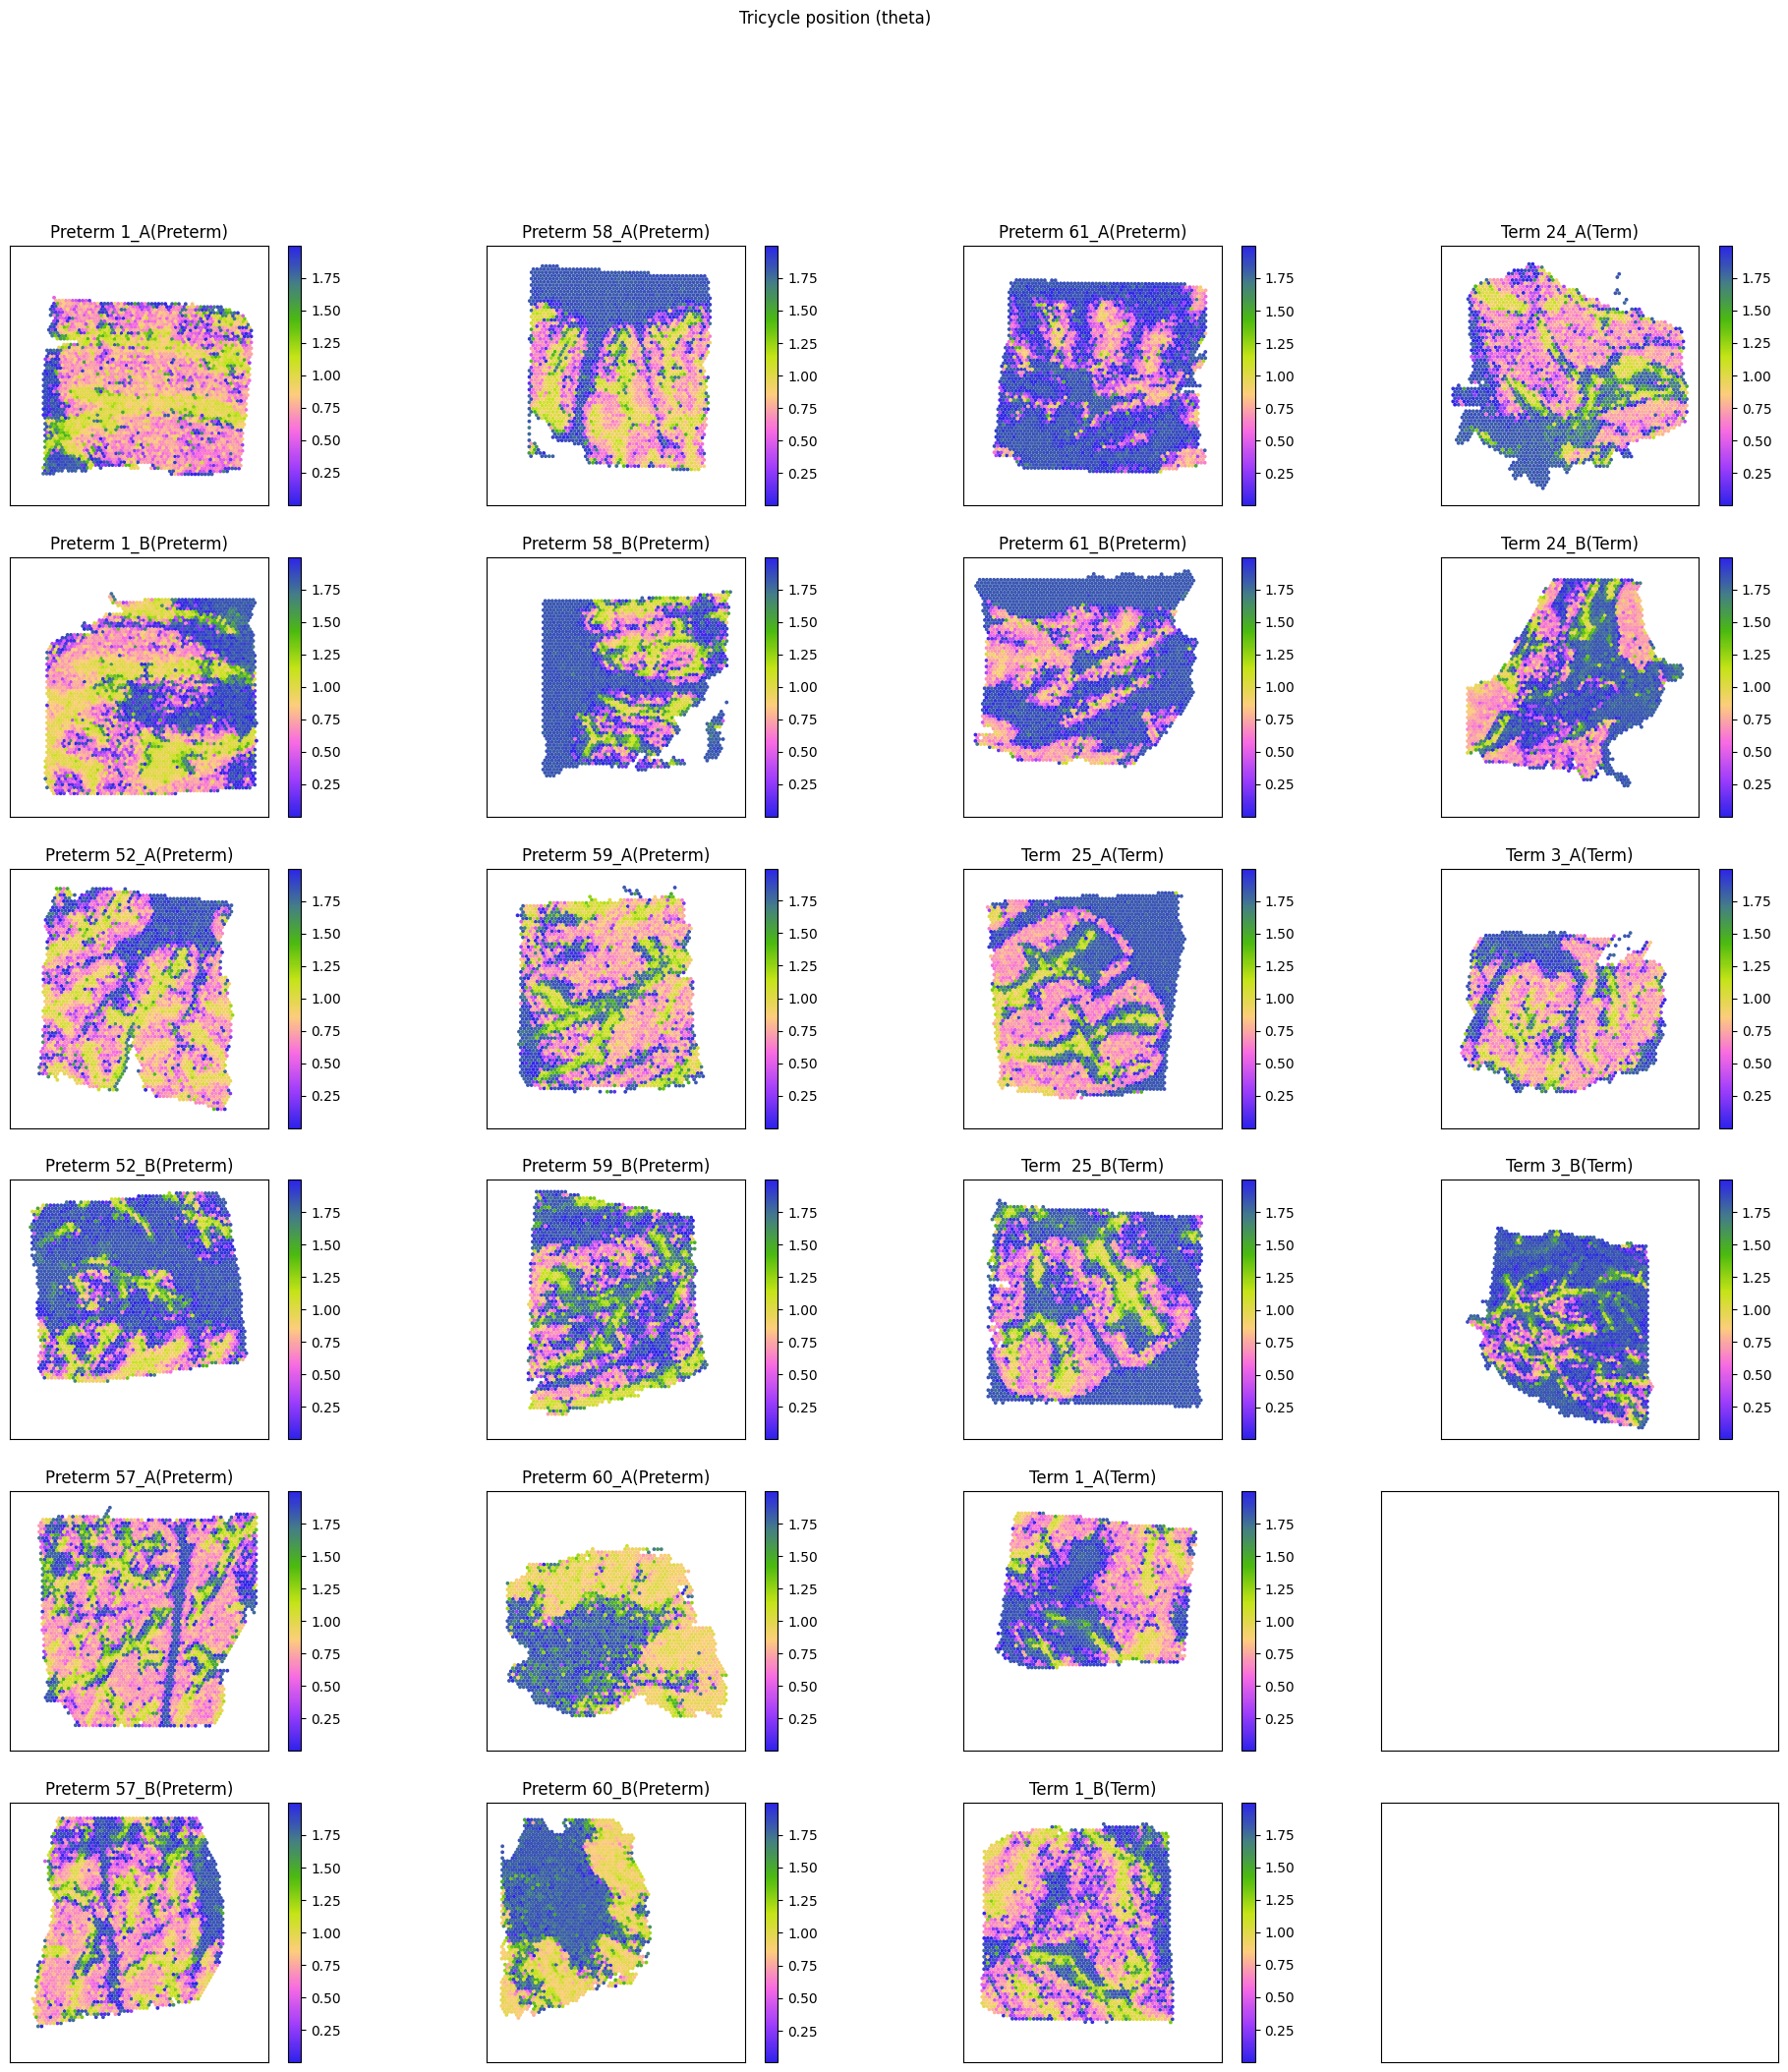

In [5]:
from matplotlib.colors import LinearSegmentedColormap
RugPalette_v = ["#2E22EA", "#9E3DFB", "#F86BE2", "#FCCE7B", "#C4E416", "#4BBA0F", "#447D87", "#2C24E9"]
rug_cmap = LinearSegmentedColormap.from_list("RugPalette", RugPalette_v)
#values = np.linspace(0, 6.28, 400)
tricycle_pos['tricyclePosition_theta'] = tricycle_pos['tricyclePosition']/np.pi

fig,axes = plt.subplots(6,4,figsize=(24,24),sharex=True,sharey=True)
fig.suptitle('Tricycle position (theta)')
i = 0
for c in range(axes.shape[1]):
        for r in range(axes.shape[0]):
            if i < len(images):
                im = images[i]
                patterns_im = tricycle_pos[tricycle_pos.index.str.contains(im)]
                axes[r,c].set(aspect='equal')
                #scat_background = axes[r,c].scatter(coords.loc[patterns_im.index,'imagerow'],coords.loc[patterns_im.index,'imagecol'], s=1, alpha=0.1,c='gray')
                #scat = axes[r,c].scatter(coords.loc[patterns_im.index,'imagerow'],coords.loc[patterns_im.index,'imagecol'], s=2, c=patterns_im['tricyclePosition'],alpha=0.8,cmap=rug_cmap)
                scat = axes[r,c].scatter(coords.loc[patterns_im.index,'imagerow'],coords.loc[patterns_im.index,'imagecol'], s=3, c=patterns_im['tricyclePosition_theta'],alpha=1,cmap=rug_cmap)

                #axes[r,c].set_box_aspect(1)
                sample = clinical_meta_cell.loc[patterns_im.index,'Patient_Replicate_PT']
                #print(sample.unique())

                axes[r,c].set_yticklabels([])
                axes[r,c].set_xticklabels([])
                axes[r,c].set_xticks([])
                axes[r,c].set_yticks([])

                axes[r,c].set_title(sample.unique()[0])
                fig.colorbar(scat, ax=axes[r,c])

                #plt.color_bar()
                #fig.colorbar(ax=ax)
                #plt.color_bar()
                i+=1

#plt.savefig('/mnt/morbo/Data/Users/kwoyshner/cerebellum/results/human_subSample/n15_plots_forPaper/tricyclePosition.pdf')
#plt.savefig('/mnt/morbo/Data/Users/kwoyshner/cerebellum/projections/tricycle/results/human_Spatial/tricyclePosition_colorAdjusted.pdf')



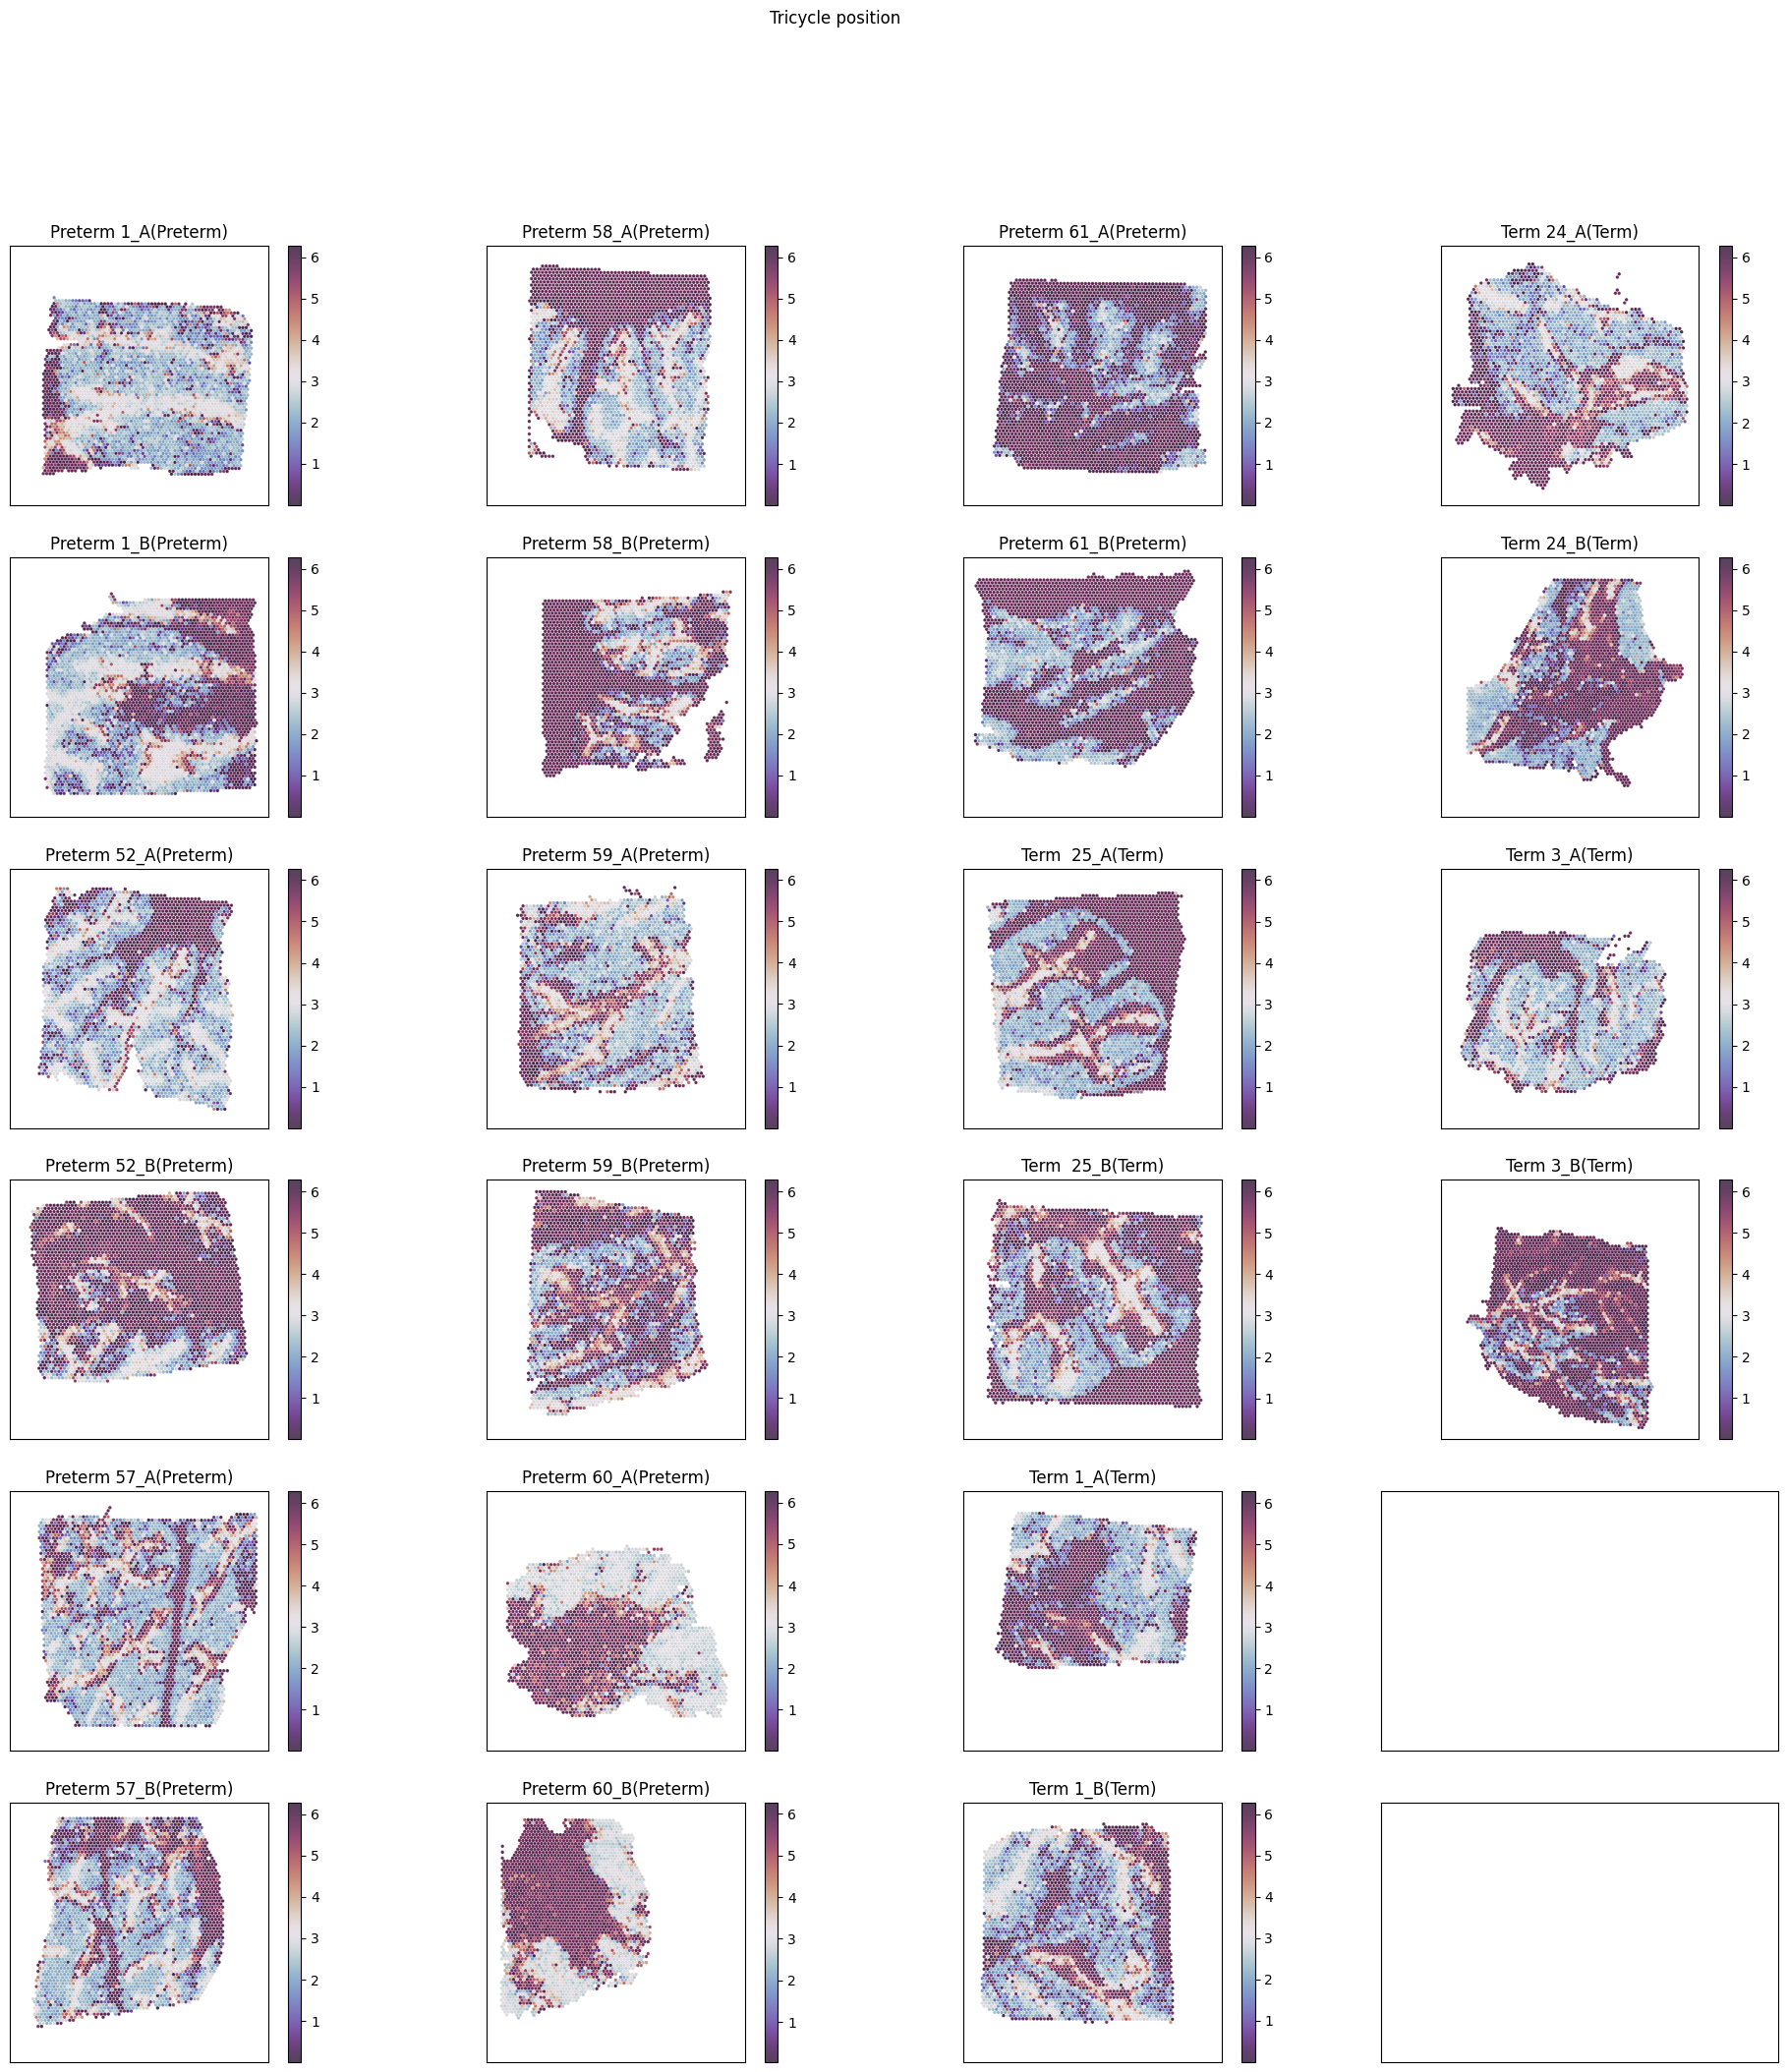

In [6]:
fig,axes = plt.subplots(6,4,figsize=(24,24),sharex=True,sharey=True)
fig.suptitle('Tricycle position')
i = 0
for c in range(axes.shape[1]):
        for r in range(axes.shape[0]):
            if i < len(images):
                im = images[i]
                patterns_im = tricycle_pos[tricycle_pos.index.str.contains(im)]
                axes[r,c].set(aspect='equal')
                scat_background = axes[r,c].scatter(coords.loc[patterns_im.index,'imagerow'],coords.loc[patterns_im.index,'imagecol'], s=1, alpha=0.1,c='gray')
                scat = axes[r,c].scatter(coords.loc[patterns_im.index,'imagerow'],coords.loc[patterns_im.index,'imagecol'], s=2, c=patterns_im['tricyclePosition'],alpha=0.8,cmap='twilight_shifted')
                #axes[r,c].set_box_aspect(1)
                sample = clinical_meta_cell.loc[patterns_im.index,'Patient_Replicate_PT']
                #print(sample.unique())

                axes[r,c].set_yticklabels([])
                axes[r,c].set_xticklabels([])
                axes[r,c].set_xticks([])
                axes[r,c].set_yticks([])

                axes[r,c].set_title(sample.unique()[0])
                fig.colorbar(scat, ax=axes[r,c])

                #plt.color_bar()
                #fig.colorbar(ax=ax)
                #plt.color_bar()
                i+=1

#plt.savefig('/mnt/morbo/Data/Users/kwoyshner/cerebellum/results/human_subSample/n15_plots_forPaper/tricyclePosition.pdf')
#plt.savefig('/mnt/morbo/Data/Users/kwoyshner/cerebellum/projections/tricycle/results/human_Spatial/tricyclePosition.pdf')

